## Exercise: Statistics - Sample vs Population Metrics

### In this notebook, we will present a series of code exercises that will test and enhance your understanding of sample and population metrics, the Central Limit Theorem (CLT), and Confidence intervals

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Differentiate between sample and population metrics
#### - Understand where the Central Limit Theorem is utilised
#### - Describe the function and measurement of confidence intervals

### Exercises

#### Suppose we are data scientists working for an environmental organization. Our task is to analyse data related to forest areas across different regions to help formulate conservation strategies. The dataset includes forest areas (in square kilometers) from over 1,000 regions worldwide

#### Exercise 1: We are working with a dataset that contains information about different species found in national parks around the world. The dataset includes data on the number of individual animals of each species found in these parks.

#### Task: Calculate the Population mean (population_mean) and variance (population_variance) of the species count

In [2]:
import pandas as pd
import numpy as np

# Generating random data. Fixed seed for reproducibility
np.random.seed(0)
forest_areas = np.random.randint(500, 10000, size=1000) # forest areas in sq km
regions = ['Region' + str(i) for i in range(1, 1001)]

# Creating a dictionary
data = {'Region': regions, 'Forest_Area':forest_areas}

# Converting to a pandas DataFrame
df = pd.DataFrame(data)

population_mean = df['Forest_Area'].mean()
population_variance = df['Forest_Area'].var(ddof=0)

#### Exercise 2: Select a random sample of 30 regions from the dataset and calculate sample mean and variance. Compare these with population metrics

In [4]:
sample_df = df.sample(n=30)

sample_mean = sample_df['Forest_Area'].mean()
sample_variance = sample_df['Forest_Area'].var(ddof=1)

In [5]:
print(f"Population vs Sample mean: {population_mean} : {sample_mean}")
print(f"Population vs Sample Variance: {population_variance} : {sample_variance}")

Population vs Sample mean: 5378.98 : 4795.2
Population vs Sample Variance: 7517438.4416 : 9662270.71724138


#### Exercise 3: Demonstrate the Central Limit Theorem (CLT) by plotting the distribution of sample means

<AxesSubplot:ylabel='Count'>

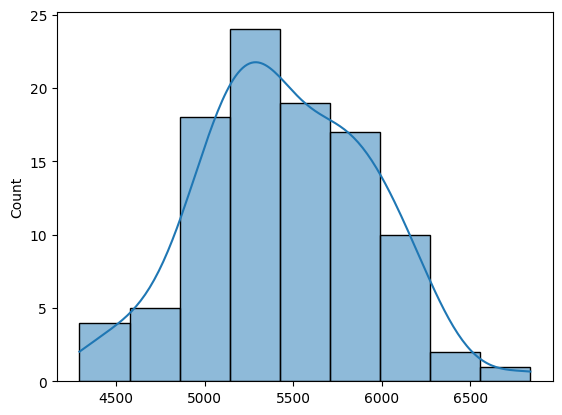

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_means = [df['Forest_Area'].sample(30).mean() for _ in range(100)]
sns.histplot(sample_means, kde=True)

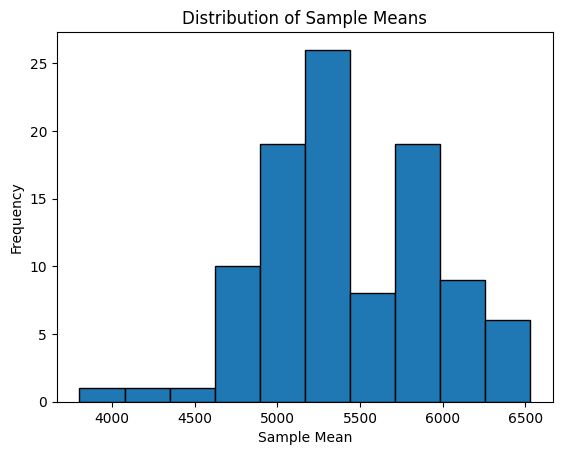

In [22]:
import matplotlib.pyplot as plt

# Take 100 samples of size 30 and plot their mean distribution
sample_means = [df['Forest_Area'].sample(30).mean() for _ in range(100)]

plt.hist(sample_means, bins=10, edgecolor='black')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means')
plt.show()

#### Exercise 4 : Calculate a 95% confidence Interval for the mean of a sample

In [26]:
from scipy import stats

np.random.seed(42)

sample_std = np.std(sample_df, ddof=1)
n = len(sample_df)

se = sample_std / np.sqrt(n)
confidence = 0.95
deg_frd = n - 1

t_critical = stats.t.ppf((1 + confidence) / 2, deg_frd)
ci = (sample_mean - t_critical * se, sample_mean + t_critical * se)

print(ci)
# print("95% confidence interval: ", ci)

(Forest_Area    3634.497147
dtype: float64, Forest_Area    5955.902853
dtype: float64)
